# Artificial Neural Networks (ANNs)

## Perceptron

- one of the simplest ANN architecture.
- based on an artificial neuron called _threshold logic unit_ (TLU) (also called _linear threshold unit_ (LTU).
- inputs and outputs are numbers.
- each input is associated with a weight.
- TLU computes the weighted sum of all these weights ($z = w_1x_1+w_2x_2+\dots+w_nx_n = \textbf{x}^T\textbf{w}$), then applies a step function on it.
- result: $h_w(\textbf{x}) = \text{step}(z)$ where $z = \textbf{x}^T\textbf{w}$

- common step functions in Perceptrons: $$ \begin{equation*}
\text{heaviside}(z) = 
\begin{cases} 
0 & \text{if } z < 0 \\ 
1 & \text{if } z \geq 0 
\end{cases}
\qquad
\operatorname{sgn}(z) = 
\begin{cases} 
-1 & \text{if } z < 0 \\ 
0 & \text{if } z = 0 \\ 
+1 & \text{if } z > 0 
\end{cases}
\end{equation*} $$
- the Heaviside step function is the most commonly used in Perceptrons.

- a single TLU can be used for simple linear binary classification.

- a Perceptron is composed of a single layer of TLUs, with each TLU connected to all the inputs.
- when all inputs in a layer are connected to every neuron in the previous layer, the layer is called _fully connected layer_ or a _dense_ layer.
- inputs of Perceptron are fed to special neurons called the _input layer_.
- an extra bias feature is added ($x_0 = 1$): it is represented using a special type of of neuron called a _bias neuron_, which outputs 1 all the time. 

- computing outputs of a fully connected layer: $h_{\textbf{W}, \textbf{b}}(\textbf{X}) = \phi(\textbf{X}\textbf{W}+\textbf{b})$
- where $\textbf{X}$ is matrix of input features. It has one row per instance and one column per feature.
- $\textbf{W}$ contains all connection weights except for the ones from the bias neuron. It has one row per input neuron and one column per artificial neuron in the layer.
- the bias vector $\textbf{b}$ contains all the connection weights between the bias neuron and the artificial neurons. It has one bias term per artificial neuron.
- the function $\phi$ is called _activation function_: when the artificial neurons are TLUs, it is a step function. 

- Perceptrons are trained using a variant of Hebb's rule that takes into account the error made by the network when it makes a prediction.
- the Perceptron is fed one training instance at a time and for each instance it makes a prediction. For every output neuron that produced a wrong prediction, it reinforces the connection weights from the inputs that would have contributed to the correct prediction.
- Perceptron learning rule (weight update): $$w_{i, j}^{(\text{next step})}=w_{i, j}+\eta(y_j-\hat{y}_j)x_i$$.
- $w_{i,j}$ is the connection weight between the $i^{\text{th}}$ input neuron and the $j^{\text{th}}$ output neuron.
- $x_i$ is the $i^{\text{th}}$ input value of the current training instance.
- $\hat{y}_j$ id the output of $j^{\text{th}}$ output neuron for the current training instance.
- $y_j$ is the target output of the $j^{\text{th}}$ output neuron for the current training instance.
- $\eta$ is the learning rate.

Perceptrons are incapable of learning complex patterns. However, if training instances are linearly separable, it can be demonstrated that this algorithm would converge to a solution. This is called _Perceptron convergence theorem_. 

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, (2,3)]
y = (iris.target == 0).astype(np.int32)

per_clf = Perceptron()
per_clf.fit(X, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [2]:
y_pred = per_clf.predict([[2, 0.5]]) 

- Perceptron learning algorithm strongly resembles SGD. Scikit-Learn's `Perceptron` class is equivalent to using `SGDClassifier` with the following hyperparameters:
    - `loss="perceptron"`
    - `learning_rate="constant"`
    - `eta0=1`
    - `penalty=None`
- Perceptrons do not output a class probablity (unlike Logistic Regression), they make predictions based on a hard threshold. 

- Limitations of Perceptrons were noted in 1969 by Marvin Minsky and Seymour Papert in their monograph _Perceptrons_.
- They highlighted serious weaknesses of Perceptrons, in particular: the fact that they are incapable of solving trivial problems (like XOR classification problem).
- Some limitations of Perceptrons can be eliminated by stacking multiple Perceptrons. The resulting ANN is called a Multilayer Perceptron (MLP). 

## Multilayer Perceptron and Backpropagation

- An MLP is composed of one _input layer_, one or more layers of TLUs (called _hidden layers_, and one final layer of TLU's called the _output layer_.
- Layers closer to input layer are called _lower layers_, and the ones closer to outputs are called the _upper layers_.
- Every layer except the output layer includes a bias neuron and is fully connected to the next layer.
- When an ANN contains a deep stack of hidden layers, it is called a _deep neural network_ (DNN). Deep learning students DNNs.
- For many years, researchers struggled to find a way to train MLPs. In 1986, Geoffrey Hinton, David Rumelhard, and Ronald Williams published a groundbreaking paper which introduced the _backpropagation_ training algorithm.
- In short, it is Gradient Descent using an efficient technique for computing the gradients automatically: in just two passes through the network, the backpropagation algorithm is able to compute the gradient of the network's error with regard to every single model parameter. In other words, it can find out how each connection weight and each bias term should be tweaked in order to reduce the error. Once it has these gradients, it just performs a regular Gradient Descent step, and the whole process is repeated until the network converges to the solution.

**Note**: Automatically calculating gradients is called _automatic differentiation_ or _autodiff_. The autodiff technique that backpropagation uses is called _reverse-mode autodiff_. 

### Backpropagation Algorithm

1. It handled one mini-batch at a time and it goes through the full training set multiple times. Each pass is called an _epoch_.
2. Each mini-batch is passed to the NN's input layer, which sends it to the first hidden layer. The algorithm then computes the output of all the neurons in this layer. The result is passed on to the next layer, its output is computed and passed to the next layer, and so on until we get the output of the last layer: the output layer. This is called the _forward pass_: it is like making predictions, except all intermediate results are preserved since they are needed for the backward pass.
3. Next, the algorithm measures the network's output error (uses a loss function to compare desired and actual output and returns some measure of the error).
4. Then it computes how much each output connection contributed to the error. This is done analytically by applying the _chain rule_.
5. The algorithm measures how much of these error contributions came from each connection in the layer below, again using the chain rule, working backwards until the algorithm reaches the input layer. This reverse pass efficiently measures the error gradient across all the connection weights in the network by propagating the error gradient backword through the network. (Insight: how do you get the gradient for connections into B? You need $\partial Loss/\partial B_{\text{output}}$ first — but B doesn't touch the loss directly. B only affects the loss indirectly, by influencing C's output. That's the whole trick. If B's output feeds into multiple neurons in C (say C1, C2, C3), then B's activation influenced the loss through three different routes. So its total responsibility for the error is the sum of its contributions along every one of those routes.) $$ \frac {\partial \text{Loss}} {\partial B_{\text{output}}} = \sum_{i \in \text{C neurons}} {\frac {\partial \text{Loss}} {\partial C_{\text{i output}}} \times \frac {\partial C_\text{i output}} {\partial B_\text{output}}}$$
6. Finally, the algorithm performs a Gradient Descent step to tweak all the connection weights in the network, using the error gradients it just computed. 

In summary, for each training instance, the backpropagation algorithm first makes a prediction (forward pass) and measures the error, then goes through each layer in reverse to measure the error contribution from each connection (reverse pass), and finally tweaks the connection weights to reduce the error (Gradient Descent step).

- It is important to initialize all the hidden layers' connection weights randomly or the model will fail. If they're all initialized to the same number, the model would behave as if it had one neuron per layer.
- In order for this algorithm to work properly, its author made a key change to the MLP's architecture: they replaced the step function with the logistic (sigmoid) function, $\sigma(z) = \frac {1} {1 + \text{exp(-z)}}$.
- This was essential because the step function contains only flat segments, so there is no gradient to work with (Gradient Descent can't move on a flat surface), while the logistic function has a well-defined nonzero derivative everywhere, allowing GD to make some progress at every step.
-  Two more activation functions backpropagation works well with:
    - **The hyperbolic tangent function**: S-sshaped, continuous, and differentiable but it's output values ranges from -1 to 1 (instead of 0 to 1 in the case of the logistic function). This range helps to make each layer's output more centered around 0 at the beginning of training, which often helps speed up convergence. $$ \text{tanh}(z) = 2\sigma(2z)-1 $$ 
    - **The Rectified Linear Unit function:** ReLU function is coninuous but not differentiable at $z=0$. $$ \text{ReLU}(z) = \text{max}(0, z) $$

**Why do we need activations?**
If we chain several linear transformations, all we get is a linear transformation (e.g., let $f(x)$ and $g(x)$ be a linear function; $f(g(x))$ will also be a linear function). So, if we don't have some non-linearity between layers, then even a deep stack of layers is equivalent to a single layer. 

## Regression MLPs

- MLPs can be used for regression.
- We need one output neuron per output dimension (if more than one output, i.e., multivariate regression).
- In general, we don't want to use activation function for output neurons, so they are free to output any range of values. If we want to guarantee the output will be positive, then ReLU activation function can be used. Alternatively, _softplus_ activation function can be used, which is a smoother variant of ReLU. $$ \text{softplus}(z) = \text{log} (1 + \text{exp}(z)) $$
- It is close to 0 when $z$ is negative and close to $z$ when z is positive.
- If we want the output to fall within a set of values, we can use logistic function or hyperbolic tangent, and then sacel the labels to fit the range (0 to 1 and -1 to 1 respectively).
- Loss function used is typically mean squared error, but if there are a lot of outliers, mean absolute error maybe preferred. Alternatively, _Huber loss_ can be used which is a mix of both.

## Classification MLPs

- MLPs can also be used for classification.
- For binary classification, we only need one output neuron using the logisticactivation function (output will be between 0 and 1), which can be interpreted as estimated probablity of the positive class.
- MLPs can also handle multilabel binary classification. You would dedicate one neuron for each positive class. Note that output probablitites do not necessarily add up to 1.
- If each instance can belong only to a single class, out of three or more possible classes (e.g., classes 0 through 0 for digit classification), then we need to have one output neuron per class, and we should use softmax activation function for the whole output layer. The softmax function will ensure that all the estimated probablities are between 0 and 1 and that they add up to 1. This is called multiclass classification. 

## Fashion MNIST

In [3]:
import tensorflow as tf
from tensorflow import keras

tf.__version__

I0000 00:00:1785496328.619197    7897 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785496328.623410    7897 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785496329.065395    7897 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785496330.107296    7897 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

'2.21.0'

In [4]:
keras.__version__

'3.12.3'

In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [6]:
X_train_full.shape

(60000, 28, 28)

In [7]:
X_train_full.dtype

dtype('uint8')

In [8]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 # create a validation set and scale pixel values down to 0-1
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
class_names[y_train[0]]

'Coat'

In [11]:
# Classification MLP with two hidden layers
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

/home/haider/anaconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1785496330.901929    7897 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


- This code snippet creates a `Sequential` model. It is the simplest kind of Keras model for NNs that composed of a single stack of layers connected sequentially. This is called the Sequential API.
- Next, we build the first layer and add it to the model. It is a `Flatten` layer whose role is to convert each input image into a 1D array. This layer does not have any parameters, it is there to do simple preprocessing. Since it's the first layer of the model, we should specify it's `input_shape`, which doesn't include the batch size only the shape of instances. Alternatively, we can use `keras.layers.InputLayer` as the first layer, setting `input_shape=[28, 28]`.
- Next, we add a `Dense` hidden layer with 300 neurons. It will use the ReLLU activation function. Each `Dense` layer manages it's own weight matrix, containing all the connection weights between the neurons and their inputs. It also manages a vector of bias terms.
- Then we add a second `Dense` layer with 100 neurons using ReLU activation function.
- Finally we add a `Dense` output layer with 10 neurons (one per class), using the softmax activation function (because classes are exclusive).

Instead of adding the layers one by one, we can pass a list of layers when creating a `Sequential` model.

In [12]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"), 
    keras.layers.Dense(10, activation="softmax")
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [15]:
hidden1 = model.layers[1]
hidden1.name

'dense_3'

In [16]:
model.get_layer('dense_3') is hidden1

True

In [17]:
weights, biases = hidden1.get_weights()

In [18]:
weights

array([[-0.00446323,  0.07062674, -0.04359695, ..., -0.06108733,
         0.05858172,  0.01237109],
       [-0.00078027, -0.05964852, -0.00592828, ...,  0.04780617,
        -0.04614621, -0.05027466],
       [ 0.02102663,  0.07397458, -0.02542954, ..., -0.05290895,
         0.02659479, -0.00893676],
       ...,
       [ 0.02925257, -0.04214679, -0.00774442, ..., -0.00753199,
        -0.02829803,  0.0004001 ],
       [-0.06651931,  0.07247558, -0.00772638, ..., -0.03748782,
        -0.00344616, -0.00558737],
       [ 0.05555318,  0.00561715, -0.01074162, ...,  0.0035627 ,
        -0.0541361 , -0.05748271]], shape=(784, 300), dtype=float32)

In [19]:
weights.shape

(784, 300)

In [20]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [21]:
biases.shape

(300,)

In [22]:
model.compile(loss="sparse_categorical_crossentropy", # loss function
              optimizer="sgd",                        # optimizer
              metrics=["accuracy"])

**Note**: When using the SGD optimizer, it is important to tune the learning rate. So, you will generally want to use optimizer=keras.optimizers.SGD(lr=???) to set the learning rate, rather than optimizer="sgd", which defaults to lr=0.01.

In [23]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7643 - loss: 0.7179 - val_accuracy: 0.8364 - val_loss: 0.4958
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8300 - loss: 0.4892 - val_accuracy: 0.8510 - val_loss: 0.4374
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8443 - loss: 0.4428 - val_accuracy: 0.8600 - val_loss: 0.4164
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8542 - loss: 0.4160 - val_accuracy: 0.8628 - val_loss: 0.3961
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8618 - loss: 0.3946 - val_accuracy: 0.8684 - val_loss: 0.3811
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8660 - loss: 0.3796 - val_accuracy: 0.8642 - val_loss: 0.3859
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8706 - loss: 0.3654 - val_accuracy: 0.8730 - val_loss: 0.3580
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8748 - loss: 0.3541 - 

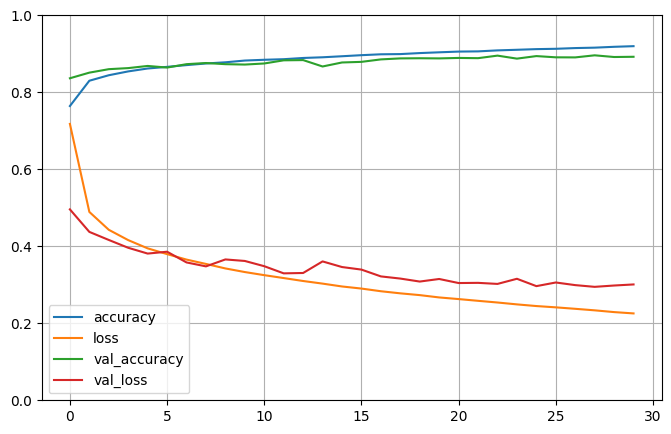

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt 

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set vertical range to [0, 1]
plt.show()

In [25]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 56.3119


[56.31187438964844, 0.8629999756813049]

In [26]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [27]:
y_pred = np.argmax(y_proba, axis=1)
y_pred

array([9, 2, 1])

In [28]:
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [29]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]), 
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

mse_test = model.evaluate(X_test, y_test)

X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20
 74/363 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - loss: 2.2889

/home/haider/anaconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0474 - val_loss: 0.6061
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - loss: 0.5179 - val_loss: 0.4834
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.4727 - val_loss: 0.4592
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4535 - val_loss: 0.4496
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.4415 - val_loss: 0.4417
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.4344 - val_loss: 0.4333
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4238 - val_loss: 0.4340
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - loss: 0.4194 - val_loss: 0.4232
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 0.4115 - val_loss: 0.4176
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4082 - val_loss: 0.4136
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - loss: 0.4029 - val_loss: 0.4128
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

In [30]:
y_pred 

array([[0.96734434],
       [2.5364733 ],
       [1.3506949 ]], dtype=float32)

## Building Complex Models Using the Functional API

- An example of nonsequential NN is a _Wide and Deep_ NN. This architecture was introduced in 2016. It connects all or part of the inputs directly to the output layer.
- This architecture makes it possible for the NN to learn both deep patterns (through deep path) and simple rules (through short path).
- In contrast, a regular MLP forces all the data to flow through the full stack of layers and thus simple patterns may end up being distorted by this sequence of transformations. 

In [31]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

In [32]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])

## Using the Subclassing API to Build Dynamic Models

- Sequential and Functional APIs are declarative.
- This means that they're static. They can't account for loops, varying shapes, conditional branching and other dynamic features in the network.
- **Subclassing API** has a more imperative programming style.
- Just subclass the `Model` class and create the layers in the constructor. Use them to perform the computations we want in the `call()` method.

In [34]:
class WideAndDeepModel(keras.Model): 
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs): 
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel()

## Saving a Model

```python
model = keras.models.Sequential([...])
model.compile([...])
model.fit([...])
model.save("model_name.h5")
```

Keras will use HDf5 format to save model's architecutre and values of all the model parameters for every layer.

Loading a model is just as easy. 

```python
model = keras.models.load_model("model_name.h5")
```

## Callbacks

- `fit()` method has a `callbacks` argument which allows us to specify a list of objects that Keras will call at the start and end of each epoch.
- `ModelCheckpoint` callback can save checkpoints of models at regular intervals during training.
- `save_best_only=True` can be set so the model is only saved when the validation set performance is the best; this prevents overfitting.

This code implements Early Stopping:
```python 
checkpoint_cb = keras.callbacks.ModelCheckpoint("model_name.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb])
model = keras.models.load_model("model_name.h5")
```

Another way to implement Early Stopping is to use the `EarlyStopping` callback:
```python
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb, early_stopping_cb])
```

## TensorBoard

- TensorBoard is a visualization tool which allows us to see learning curves, compare learning curves between runs and visualize computation graph, analyze training statistics and more.
- To use this, we must output the data we want to visualize to binary files, called _event files_. Each data record is called a _summary_.

In [36]:
import os
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

```python 
[...] # Build and compile your model
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid), callbacks=[tensorboard_cb])
```

To start the TensorBoard server:
```bash
$ tensorboard --logdir=./my_logs --port=6006
```
or using Jupyter: 
```
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006
```

## Fine-Tuning a Neural Network

- There are many hyperparameters to tweak in a regular NN.
- We have to wrap the model in objects that mimic regular Scikit-Learn regressors; so we can try combinations of hyperparameters such as `GridSearchCV` or `RandomizedSearchCV`.

In [46]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model 

In [47]:
%pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [48]:
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(build_model)

In [49]:
keras_reg.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1621 - val_loss: 0.6741
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6732 - val_loss: 0.6644
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5801 - val_loss: 0.5310
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss: 0.5208 - val_loss: 0.5002
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 0.4911 - val_loss: 0.4813
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4764 - val_loss: 0.4727
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4672 - val_loss: 0.4667
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - loss: 0.4601 - val_loss: 0.4593
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4553 - val_loss: 0.4536
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4492 - val_loss: 0.4506
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - loss: 0.4466 - val_loss: 0.4501
Epoch 12/100
363/363 ━━━━━━━━━━━━

In [ ]:
from scipy.stats import reciprocal 
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    "model__n_hidden": [0, 1, 2, 3],
    "model__n_neurons": np.arange(1, 100), 
    "model__learning_rate": reciprocal(3e-4, 3e-2), 
}

rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3)
rnd_search_cv.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[keras.callbacks.EarlyStopping(patience=10)])

In [ ]:
rnd_search_cv.best_params__
rnd_search_cv.best_score_
model = rnd_search_cv.best_estimator_.model